In [9]:
import os

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split


In [10]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = "../data/processed/augmented/"

X_DIR = "../data/processed/patches/X.npy"
Y_DIR = "../data/processed/patches/Y.npy"

X = np.load(X_DIR).astype(np.float32)
Y = np.load(Y_DIR).astype(np.float32)

print("X shape:", X.shape, "dtype:", X.dtype, "min/max:", X.min(), X.max())
print("Y shape:", Y.shape, "dtype:", Y.dtype, "min/max:", Y.min(), Y.max())

print("Foreground pixel ratio:", np.mean(Y))

X shape: (136, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Y shape: (136, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Foreground pixel ratio: 0.10538225


In [11]:
# for identical stateless geometric transforms to image and mask

def paired_augmentation(image, mask, seed=None):
    if seed is None:
        seed = SEED

    image = tf.convert_to_tensor(image, dtype=tf.float32)
    mask = tf.convert_to_tensor(mask, dtype=tf.float32)
    combined = tf.concat([image, mask], axis=-1)

    combined = tf.image.stateless_random_flip_left_right(
        combined,
        seed=[seed, 1]
    )

    combined = tf.image.stateless_random_flip_up_down(
        combined,
        seed=[seed, 2]
    )

    rotation_k = tf.random.stateless_uniform(
        shape=[],
        seed=[seed, 3],
        minval=0,
        maxval=4,
        dtype=tf.int32
    )
    combined = tf.image.rot90(combined, k=rotation_k)

    augmented_image = combined[..., :1]
    augmented_mask = tf.cast(
        combined[..., 1:] >= 0.5,
        tf.float32
    )

    return augmented_image, augmented_mask

# for synchronized geometry and image-only TensorFlow intensity changes
def paired_augmentation_with_intensity(image, mask, seed=None):
    if seed is None:
        seed = SEED

    image, mask = paired_augmentation(image, mask, seed=seed)

    image = tf.image.stateless_random_brightness(
        image,
        max_delta=0.08,
        seed=[seed, 4]
    )
    image = tf.image.stateless_random_contrast(
        image,
        lower=0.9,
        upper=1.1,
        seed=[seed, 5]
    )
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask

In [12]:
def test_augmentation_invariants(X, Y, indices):
    failures = []

    for index in indices:
        # image = tf.convert_to_tensor(X[index], dtype=tf.float32)
        # mask = tf.convert_to_tensor(Y[index], dtype=tf.float32)
        image = X[index]
        mask = Y[index]
        original_foreground = float(tf.reduce_sum(mask))

        for repeat in range(10):
            seed = SEED + int(index) * 100 + repeat
            augmented_image, augmented_mask = (
                paired_augmentation_with_intensity(
                    image,
                    mask,
                    seed=seed
                )
            )

            augmented_foreground = float(tf.reduce_sum(augmented_mask))
            binary_values = np.unique(augmented_mask.numpy())

            # Using the mask as both channels directly checks geometric synchronization.
            sync_image, sync_mask = paired_augmentation(
                mask,
                mask,
                seed=seed
            )

            if original_foreground != augmented_foreground:
                failures.append(
                    f"Patch {index}: foreground changed from "
                    f"{original_foreground} to {augmented_foreground}"
                )

            if not np.all(np.isin(binary_values, [0.0, 1.0])):
                failures.append(
                    f"Patch {index}: non-binary mask values "
                    f"{binary_values[:10]}"
                )

            if not np.array_equal(sync_image.numpy(), sync_mask.numpy()):
                failures.append(
                    f"Patch {index}: image and mask geometry are not synchronized"
                )

            if (
                float(tf.reduce_min(augmented_image)) < 0.0
                or float(tf.reduce_max(augmented_image)) > 1.0
            ):
                failures.append(
                    f"Patch {index}: augmented image is outside [0, 1]"
                )

    if failures:
        print("AUGMENTATION TEST FAILED")
        for failure in failures[:20]:
            print("-", failure)
        return False

    print("AUGMENTATION TEST PASSED")
    print("Geometry stays synchronized, masks remain binary,")
    print("foreground area is preserved, and images remain in [0, 1].")
    return True


# candidate_indices = np.arange(len(X))
# indices_to_test = candidate_indices[:10]


assert test_augmentation_invariants(
    X, Y, np.arange(min(10, len(X)))
)

AUGMENTATION TEST PASSED
Geometry stays synchronized, masks remain binary,
foreground area is preserved, and images remain in [0, 1].


In [13]:
def augment_dataset(X_train, Y_train, augment_factor=3, seed=SEED):
    X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
    Y_train = tf.convert_to_tensor(Y_train, dtype=tf.float32)

    image_batches = [X_train]
    mask_batches = [Y_train]

    for augmentation_index in range(augment_factor):
        augmented_images = []
        augmented_masks = []

        for patch_index in range(len(X_train)):
            sample_seed = (
                seed
                + (augmentation_index + 1) * 100_000
                + patch_index
            )
            image, mask = paired_augmentation_with_intensity(
                X_train[patch_index],
                Y_train[patch_index],
                seed=sample_seed
            )
            augmented_images.append(image)
            augmented_masks.append(mask)

        image_batches.append(tf.stack(augmented_images))
        mask_batches.append(tf.stack(augmented_masks))

    X_aug = tf.concat(image_batches, axis=0)
    Y_aug = tf.concat(mask_batches, axis=0)

    return (
        X_aug.numpy(),
        Y_aug.numpy()
    )

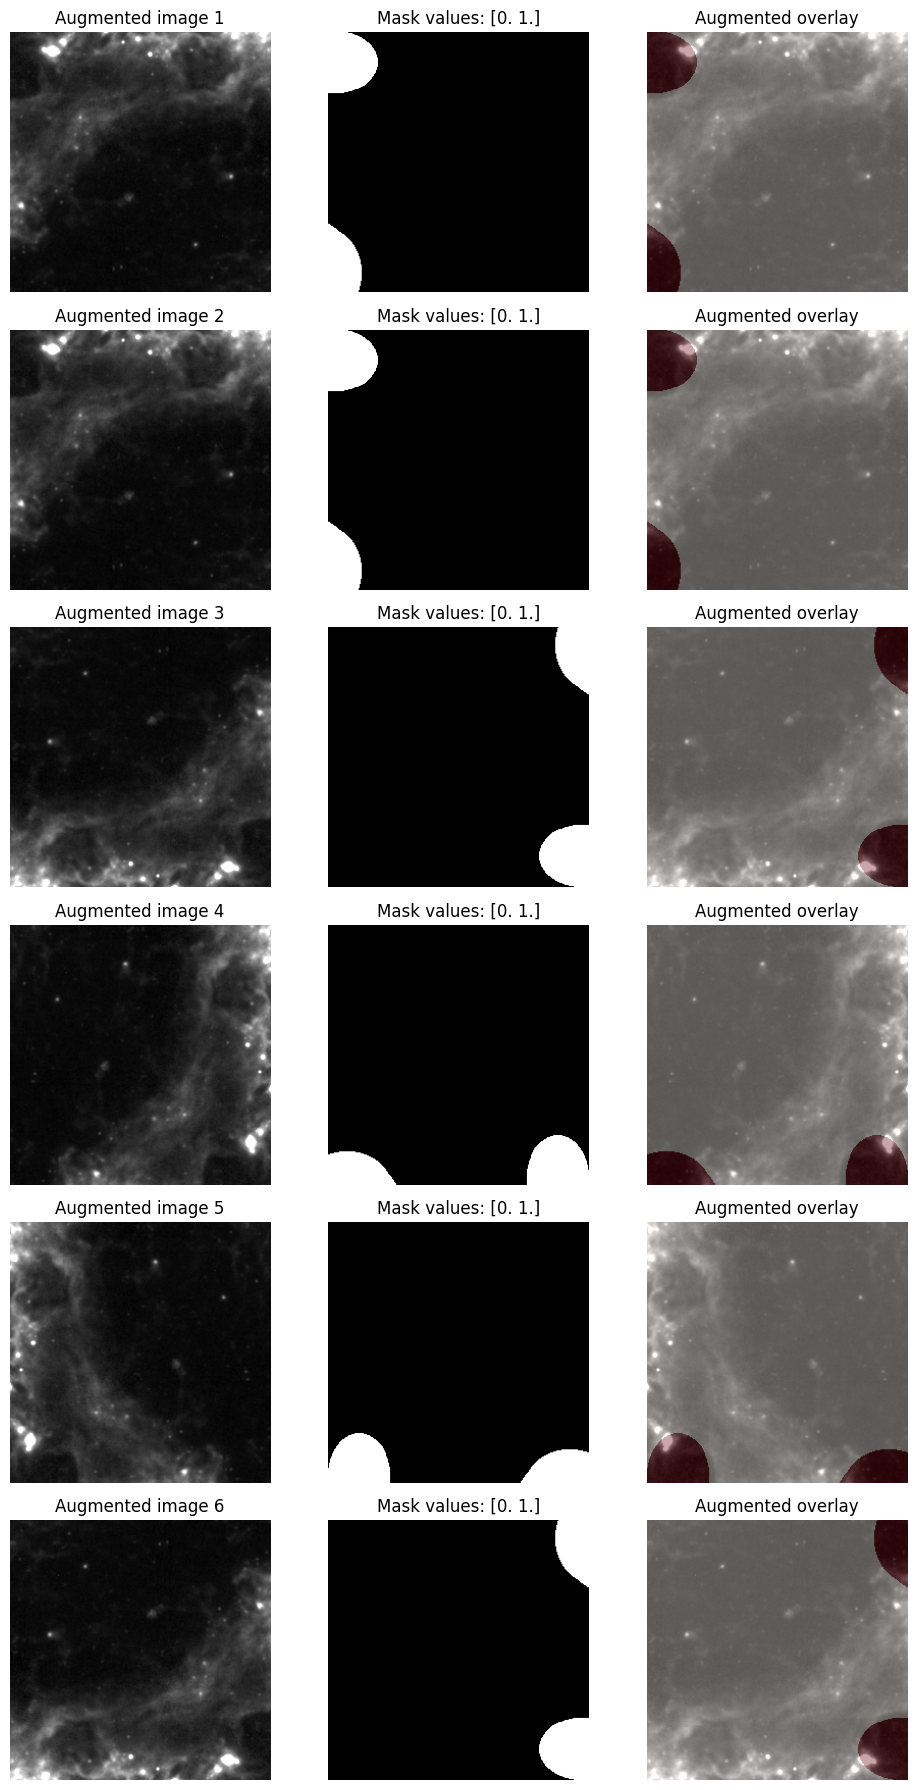

In [14]:
def show_augmentation_test(X, Y, patch_index, repetitions=6):
    image = tf.convert_to_tensor(X[patch_index])
    mask = tf.convert_to_tensor(Y[patch_index])

    fig, axes = plt.subplots(
        repetitions,
        3,
        figsize=(10, 3 * repetitions)
    )

    for row in range(repetitions):
        augmented_image, augmented_mask = (
            paired_augmentation_with_intensity(
                image,
                mask,
                seed=SEED + row
            )
        )

        augmented_image = augmented_image.numpy()[..., 0]
        augmented_mask = augmented_mask.numpy()[..., 0]

        axes[row, 0].imshow(
            augmented_image,
            origin="lower",
            cmap="gray"
        )
        axes[row, 0].set_title(f"Augmented image {row + 1}")

        axes[row, 1].imshow(
            augmented_mask,
            origin="lower",
            cmap="gray"
        )
        axes[row, 1].set_title(
            f"Mask values: {np.unique(augmented_mask)}"
        )

        axes[row, 2].imshow(
            augmented_image,
            origin="lower",
            cmap="gray"
        )
        axes[row, 2].imshow(
            augmented_mask,
            origin="lower",
            cmap="Reds",
            alpha=0.35
        )
        axes[row, 2].set_title("Augmented overlay")

        for column in range(3):
            axes[row, column].axis("off")

    plt.tight_layout()
    plt.show()


foreground_ratios = Y.mean(axis=(1, 2, 3))
candidate_indices = np.where(foreground_ratios > 0.05)[0]

test_patch_index = candidate_indices[0]

show_augmentation_test(
    X,
    Y,
    patch_index=test_patch_index
)

In [15]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)

print("Before augmentation:")
print("X_train:", X_train.shape, type(X_train))
print("Y_train:", Y_train.shape, type(Y_train))
print("X_val:", X_val.shape, type(X_val))
print("Y_val:", Y_val.shape, type(Y_val))

X_train_aug, Y_train_aug = augment_dataset(
    X_train,
    Y_train,
    augment_factor=3
)

print("\nAfter augmentation:")
print("X_train_aug:", X_train_aug.shape, type(X_train_aug))
print("Y_train_aug:", Y_train_aug.shape, type(Y_train_aug))
print("X_val:", X_val.shape, type(X_val))
print("Y_val:", Y_val.shape, type(Y_val))

Before augmentation:
X_train: (108, 256, 256, 1) <class 'numpy.ndarray'>
Y_train: (108, 256, 256, 1) <class 'numpy.ndarray'>
X_val: (28, 256, 256, 1) <class 'numpy.ndarray'>
Y_val: (28, 256, 256, 1) <class 'numpy.ndarray'>

After augmentation:
X_train_aug: (432, 256, 256, 1) <class 'numpy.ndarray'>
Y_train_aug: (432, 256, 256, 1) <class 'numpy.ndarray'>
X_val: (28, 256, 256, 1) <class 'numpy.ndarray'>
Y_val: (28, 256, 256, 1) <class 'numpy.ndarray'>


In [16]:
# Save augmented training data and untouched validation data as NumPy arrays.
os.makedirs(OUTPUT_DIR, exist_ok=True)

outputs = {
    "XtrainAug.npy": X_train_aug,
    "YtrainAug.npy": Y_train_aug,
    "Xval.npy": X_val,
    "Yval.npy": Y_val,
}

for filename, array in outputs.items():
    array = np.asarray(array, dtype=np.float32)
    output_path = os.path.join(OUTPUT_DIR, filename)
    np.save(output_path, array)
    print(f"Saved {filename}: shape={array.shape}, dtype={array.dtype}")

Saved XtrainAug.npy: shape=(432, 256, 256, 1), dtype=float32
Saved YtrainAug.npy: shape=(432, 256, 256, 1), dtype=float32
Saved Xval.npy: shape=(28, 256, 256, 1), dtype=float32
Saved Yval.npy: shape=(28, 256, 256, 1), dtype=float32
